# THE AUTONOMOUS COMPLIANCE SENTINEL

In [1]:
import pandas as pd

df_jira = pd.read_csv("GFG_FINAL.csv")  
df_jira.head()

,Summary,Issue key,Issue id,Issue Type,Status,Project key,Project name,Project type,Project lead,Project description,...,Comment.75,Comment.76,Comment.77,Comment.78,Comment.79,Comment.80,Comment.81,Comment.82,Comment.83,Comment.84
0,Sourcetree repository tab width automatically ...,SRCTREEWIN-14221,1949800,Bug,Short Term Backlog,SRCTREEWIN,Sourcetree for Windows,software,rgomis,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Stashes don't show untracked files when clicki...,SRCTREEWIN-14215,1946072,Bug,Short Term Backlog,SRCTREEWIN,Sourcetree for Windows,software,rgomis,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Beyond compare not starting,SRCTREEWIN-14211,1945187,Bug,Gathering Impact,SRCTREEWIN,Sourcetree for Windows,software,rgomis,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Displaying all changes between hash1 and hash2...,SRCTREEWIN-14210,1945171,Bug,Closed,SRCTREEWIN,Sourcetree for Windows,software,rgomis,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Displaying all changes between hash1 and hash2...,SRCTREEWIN-14209,1945161,Bug,Closed,SRCTREEWIN,Sourcetree for Windows,software,rgomis,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df_jira.columns

Index(['Summary', 'Issue key', 'Issue id', 'Issue Type', 'Status',
       'Project key', 'Project name', 'Project type', 'Project lead',
       'Project description',
       ...
       'Comment.75', 'Comment.76', 'Comment.77', 'Comment.78', 'Comment.79',
       'Comment.80', 'Comment.81', 'Comment.82', 'Comment.83', 'Comment.84'],
      dtype='object', length=491)

In [3]:
df_jira = df_jira.dropna(subset=["Description"])
df_jira.shape

(49000, 491)

In [4]:
df_jira["Summary"].sample(10)

3596                          We need an offline Installer
40701     Cannot get past "Registration" step of installer
28948     Default Web Browser Not Recognized - Source Tree
29446         spell check of commit messages does not work
35062    Sourcetree reproducable fails for a basic use ...
44749                         not saving remote login data
30088           Source Tree Application Crashes on Opening
18494                        git-svn support does not work
13384      Local branch does not appear in push dialog box
13437                Logical tree level for local branches
Name: Summary, dtype: object

In [5]:
df_jira["Description"].sample(5)

33429    I have setup Sourcetree so that it does not st...
21206    Hi all,on Windows 10 (64bit) with the Dark The...
13487    SourceTree Windows updated yesterday to 3.4.2,...
27915    I originally could not create a branch due to ...
24616    Hello,when I switch to remote tab (remote repo...
Name: Description, dtype: object

# Regulatory Analysis

The Compliance Sentinel system is designed in the regulatory context of the
EU AI Act and GDPR. The system evaluates AI project proposals prior to development and classifies them according to potential regulatory risk categories.

The model detects indicators of prohibited AI practices (e.g., social scoring, biometric surveillance) and high-risk systems (e.g., automated hiring, predictive profiling). These categories align with the EU AI Act risk-based classification framework.

Additionally, GDPR principles such as lawfulness, transparency, and data minimization are considered in cases involving personal data processing and external data sourcing.

The system functions as a preliminary compliance screening mechanism and does not replace formal legal review. Instead, it reduces regulatory exposure by identifying high-risk initiatives at early proposal stages.

# Proposals Generator with Ethical red flags Injection

In [6]:
RISK_VARIATIONS = {
    "employment_ai": [
        "The recruitment workflow will leverage algorithmic candidate prioritization.",
        "Applicant suitability assessments will be derived from historical performance indicators.",
        "Shortlisting decisions will rely on automated scoring mechanisms.",
        "Hiring recommendations will be generated through predictive evaluation models."
    ],

    "behavioral_profiling": [
        "Customer interaction data will be analyzed to derive behavioral patterns.",
        "Historical activity trends will inform future risk categorization.",
        "Individual engagement signals will be used for predictive segmentation.",
        "Behavior-driven analytics will support strategic prioritization."
    ],

    "biometric_monitoring": [
        "Visual identity verification tools will enhance access control efficiency.",
        "Live video feeds may be analyzed to improve situational awareness.",
        "Camera-based identity analytics will support internal monitoring processes."
    ],

    "reputation_scoring": [
        "A composite behavioral index will influence service eligibility tiers.",
        "Aggregated interaction metrics will determine prioritization levels.",
        "User reliability indicators will inform automated decision flows."
    ]
}

SAFEGUARD_VARIATIONS = [
    "Governance measures will be defined during implementation.",
    "Manual review processes may be incorporated where appropriate.",
    "Regulatory alignment will be periodically assessed.",
    "Oversight structures are expected to evolve alongside deployment.",
    "Compliance documentation will be maintained where required."
]

BUSINESS_NOISE = [
    "The solution will integrate with existing enterprise platforms.",
    "Scalability and performance benchmarks will be continuously monitored.",
    "Cross-departmental collaboration will ensure smooth deployment.",
    "Cloud-native infrastructure will support modular expansion.",
    "Operational efficiency gains are anticipated."
]

import random
import uuid

departments = [
    "Human Resources",
    "Risk Management",
    "Customer Analytics",
    "Security Operations",
    "Finance",
    "IT Governance"
]

strategic_goals = [
    "enhance operational efficiency",
    "optimize decision workflows",
    "improve risk visibility",
    "increase automation maturity",
    "strengthen data-driven planning"
]

def generate_realistic_proposal(is_risky=False):

    dept = random.choice(departments)
    goal = random.choice(strategic_goals)

    title = f"{dept} AI Initiative – {str(uuid.uuid4())[:6]}"

    base_text = (
        f"The {dept} department has identified an opportunity to {goal}. "
        f"This initiative aims to leverage advanced analytics capabilities. "
    )

    # Add noise
    noise_sentences = " ".join(random.sample(BUSINESS_NOISE, 2))

    description = base_text + noise_sentences + " "

    violation_category = None

    if is_risky:
        violation_category = random.choice(list(RISK_VARIATIONS.keys()))
        risk_text = random.choice(RISK_VARIATIONS[violation_category])

        description += risk_text

        # 30% chance of adding vague safeguard (makes classification harder)
        if random.random() < 0.3:
            description += " " + random.choice(SAFEGUARD_VARIATIONS)

        label = "red_flag"

    else:
        # Clean proposals still mention analytics (realistic)
        description += random.choice(SAFEGUARD_VARIATIONS)
        label = "clean"

    return {
        "title": title,
        "description": description.strip(),
        "risk_label": label,
        "violation_category": violation_category
    }


proposals = []

for _ in range(500):
    proposals.append(generate_realistic_proposal(False))

for _ in range(500):
    proposals.append(generate_realistic_proposal(True))

random.shuffle(proposals)

df_proposals = pd.DataFrame(proposals)

print(df_proposals["risk_label"].value_counts())

risk_label
clean       500
red_flag    500
Name: count, dtype: int64


# Connection to JIRA

In [7]:
import requests
import json
from requests.auth import HTTPBasicAuth

EMAIL = "YOUR_EMAIL"
API_TOKEN = "YOUR_API_TOKEN"
BASE_URL = "https://compliance-sentinel-demo1.atlassian.net"


url = f"{BASE_URL}/rest/api/3/issue"

payload = {
    "fields": {
        "project": {"key": "KAN"},
        "summary": "Test Compliance Proposal - Red Flag",
        "description": {
            "type": "doc",
            "version": 1,
            "content": [
                {
                    "type": "paragraph",
                    "content": [
                        {
                            "type": "text",
                            "text": "This system uses automated hiring decisions without human review."
                        }
                    ]
                }
            ]
        },
        "issuetype": {"name": "Task"},
        "labels": ["red_flag"]
    }
}

response = requests.post(
    url,
    data=json.dumps(payload),
    auth=HTTPBasicAuth(EMAIL, API_TOKEN),
    headers={
        "Accept": "application/json",
        "Content-Type": "application/json"
    }
)

print("Status:", response.status_code)
print(response.text)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Status: 201
{"id":"16017","key":"KAN-5890","self":"https://compliance-sentinel-demo1.atlassian.net/rest/api/3/issue/16017"}


# Ingestion to JIRA real world

In [8]:
import requests
import json
import time
from requests.auth import HTTPBasicAuth

# ---------------------------
# CONFIGURATION
# ---------------------------
EMAIL = "YOUR_EMAIL"
API_TOKEN = "YOUR_API_TOKEN"
BASE_URL = "https://compliance-sentinel-demo1.atlassian.net"

PROJECT_KEY = "KAN" #CHANGE ACCORDING TO YOUR PROJECT KEY IN JIRA

CREATE_URL = f"{BASE_URL}/rest/api/3/issue"

auth = HTTPBasicAuth(EMAIL, API_TOKEN)

headers = {
    "Accept": "application/json",
    "Content-Type": "application/json"
}

# ---------------------------
# Convert plain text → ADF format
# ---------------------------
def to_adf(text):
    return {
        "type": "doc",
        "version": 1,
        "content": [
            {
                "type": "paragraph",
                "content": [
                    {
                        "type": "text",
                        "text": text
                    }
                ]
            }
        ]
    }

# ---------------------------
# Upload Function
# ---------------------------
def upload_proposals(df, delay=0.4):
    
    success_count = 0
    fail_count = 0
    failed_items = []
    
    for index, row in df.iterrows():
        
        payload = {
            "fields": {
                "project": {"key": PROJECT_KEY},
                "summary": row["title"],
                "description": to_adf(row["description"]),
                "issuetype": {"name": "Task"}
            }
        }
        
        response = requests.post(
            CREATE_URL,
            auth=auth,
            headers=headers,
            data=json.dumps(payload)
        )
        
        if response.status_code == 201:
            success_count += 1
        else:
            fail_count += 1
            failed_items.append({
                "index": index,
                "status": response.status_code,
                "response": response.text
            })
        
        # Rate limit protection
        time.sleep(delay)
        
        # Progress log every 50
        if (index + 1) % 50 == 0:
            print(f"Uploaded {index+1} issues...")

    print("\nUpload Completed")
    print("Successful:", success_count)
    print("Failed:", fail_count)
    
    return failed_items

# ---------------------------
# EXECUTE UPLOAD
# ---------------------------
failed_logs = upload_proposals(df_proposals, delay=0.4)

Uploaded 50 issues...
Uploaded 100 issues...
Uploaded 150 issues...
Uploaded 200 issues...
Uploaded 250 issues...
Uploaded 300 issues...
Uploaded 350 issues...
Uploaded 400 issues...
Uploaded 450 issues...
Uploaded 500 issues...
Uploaded 550 issues...
Uploaded 600 issues...
Uploaded 650 issues...
Uploaded 700 issues...
Uploaded 750 issues...
Uploaded 800 issues...
Uploaded 850 issues...
Uploaded 900 issues...
Uploaded 950 issues...
Uploaded 1000 issues...

Upload Completed
Successful: 1000
Failed: 0


# Retrival from JIRA

In [9]:
import requests
import pandas as pd
from requests.auth import HTTPBasicAuth

EMAIL = "YOUR_MAIL"
API_TOKEN = "YOUR_API_TOKEN"
BASE_URL = "https://compliance-sentinel-demo1.atlassian.net"

SEARCH_URL = f"{BASE_URL}/rest/api/3/search/jql"

auth = HTTPBasicAuth(EMAIL, API_TOKEN)

headers = {"Accept": "application/json"}

def extract_text_from_adf(adf):
    if not adf:
        return ""
    text_content = []
    for block in adf.get("content", []):
        for inner in block.get("content", []):
            if inner.get("type") == "text":
                text_content.append(inner.get("text", ""))
    return " ".join(text_content)

all_issues = []
next_page_token = None

while True:

    params = {
        "jql": 'project = "My Data Science Team"',
        "maxResults": 100,
        "fields": "summary,description,created"
    }

    if next_page_token:
        params["nextPageToken"] = next_page_token

    response = requests.get(
        SEARCH_URL,
        params=params,
        auth=auth,
        headers=headers
    )

    data = response.json()
    issues = data.get("issues", [])

    if not issues:
        break

    for issue in issues:
        summary = issue["fields"].get("summary", "")
        description_adf = issue["fields"].get("description", {})
        description_text = extract_text_from_adf(description_adf)

        all_issues.append({
            "key": issue.get("key"),
            "summary": summary,
            "description": description_text,
            "created": issue["fields"].get("created")
        })

    print(f"Retrieved {len(all_issues)} issues so far...")

    next_page_token = data.get("nextPageToken")

    if not next_page_token:
        break

df_jira_live = pd.DataFrame(all_issues)

print("\nFinal Retrieved Rows:", len(df_jira_live))
df_jira_live.head()

Retrieved 100 issues so far...
Retrieved 200 issues so far...
Retrieved 300 issues so far...
Retrieved 400 issues so far...
Retrieved 500 issues so far...
Retrieved 600 issues so far...
Retrieved 700 issues so far...
Retrieved 800 issues so far...
Retrieved 900 issues so far...
Retrieved 1000 issues so far...
Retrieved 1100 issues so far...
Retrieved 1200 issues so far...
Retrieved 1300 issues so far...
Retrieved 1400 issues so far...
Retrieved 1500 issues so far...
Retrieved 1600 issues so far...
Retrieved 1700 issues so far...
Retrieved 1800 issues so far...
Retrieved 1900 issues so far...
Retrieved 2000 issues so far...
Retrieved 2100 issues so far...
Retrieved 2200 issues so far...
Retrieved 2300 issues so far...
Retrieved 2400 issues so far...
Retrieved 2500 issues so far...
Retrieved 2600 issues so far...
Retrieved 2700 issues so far...
Retrieved 2800 issues so far...
Retrieved 2900 issues so far...
Retrieved 3000 issues so far...
Retrieved 3100 issues so far...
Retrieved 3200 is

,key,summary,description,created
0,KAN-6890,Finance AI Initiative – 50e845,The Finance department has identified an oppor...,2026-03-07T00:11:16.118+0100
1,KAN-6889,IT Governance AI Initiative – 6a27b8,The IT Governance department has identified an...,2026-03-07T00:11:14.792+0100
2,KAN-6888,Security Operations AI Initiative – 9878fa,The Security Operations department has identif...,2026-03-07T00:11:13.562+0100
3,KAN-6887,Finance AI Initiative – 8d5292,The Finance department has identified an oppor...,2026-03-07T00:11:12.326+0100
4,KAN-6886,Human Resources AI Initiative – e8b16f,The Human Resources department has identified ...,2026-03-07T00:11:11.199+0100


In [10]:
regulatory_corpus = {
    "prohibited_social_scoring": """
    AI systems that evaluate or classify individuals based on behavior,
    trustworthiness, reputation, or aggregated personal data to produce
    a social score affecting their treatment.
    """,

    "prohibited_biometric_surveillance": """
    AI systems performing real-time remote biometric identification,
    including facial recognition in public or workplace environments.
    """,

    "high_risk_employment": """
    AI systems used for recruitment, candidate evaluation,
    automated employment decisions, or ranking applicants
    without meaningful human oversight.
    """,

    "high_risk_profiling": """
    AI systems that profile individuals using historical behavioral
    patterns or predictive risk indicators that may significantly
    affect individuals.
    """
}

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

all_texts = list(regulatory_corpus.values()) + list(df_proposals["description"])

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(all_texts)

reg_vectors = tfidf_matrix[:len(regulatory_corpus)]
proposal_vectors = tfidf_matrix[len(regulatory_corpus):]

similarity_matrix = cosine_similarity(proposal_vectors, reg_vectors)

threshold = 0.15  # tune later

predicted_labels = []
risk_types = []

for sim_scores in similarity_matrix:
    max_score = np.max(sim_scores)
    max_index = np.argmax(sim_scores)

    if max_score > threshold:
        predicted_labels.append("red_flag")
        risk_types.append(list(regulatory_corpus.keys())[max_index])
    else:
        predicted_labels.append("clean")
        risk_types.append(None)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(
    df_proposals["risk_label"],
    predicted_labels
))

              precision    recall  f1-score   support

       clean       0.51      1.00      0.68       500
    red_flag       1.00      0.04      0.08       500

    accuracy                           0.52      1000
   macro avg       0.76      0.52      0.38      1000
weighted avg       0.76      0.52      0.38      1000



# Machine-Learning Model (Logistic regression) 

In [13]:
from sklearn.model_selection import train_test_split

X = df_proposals["description"]
y = df_proposals["risk_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


y_pred = model.predict(X_test_vec)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:

[[100   0]
 [  0 100]]

Classification Report:

              precision    recall  f1-score   support

       clean       1.00      1.00      1.00       100
    red_flag       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Generating Adversarial Data for evaluation

In [15]:
ADVERSARIAL_RISK = [
    "The system will support structured prioritization of applicants based on performance indicators.",
    "Historical interaction patterns will inform operational decision flows.",
    "Behavioral signals will influence service allocation strategies.",
    "Engagement metrics may guide internal classification processes.",
    "Analytical models will assist in ranking internal entities."
]

ADVERSARIAL_CLEAN = [
    "Advanced analytics will support internal dashboards for monitoring performance trends.",
    "Automated reporting workflows will improve operational transparency.",
    "Data-driven insights will assist managerial review processes.",
    "Machine learning models will generate aggregated business metrics.",
    "Predictive tools will support high-level strategic forecasting without individual-level decisions."
]

def generate_adversarial_proposal(is_risky=False):

    dept = random.choice(departments)
    goal = random.choice(strategic_goals)

    base_text = (
        f"The {dept} department seeks to {goal}. "
        f"The initiative aims to modernize analytics capabilities. "
    )

    noise = " ".join(random.sample(BUSINESS_NOISE, 2))

    if is_risky:
        description = base_text + noise + " " + random.choice(ADVERSARIAL_RISK)
        label = "red_flag"
    else:
        description = base_text + noise + " " + random.choice(ADVERSARIAL_CLEAN)
        label = "clean"

    return {
        "description": description,
        "risk_label": label
    }


adversarial_data = []

for _ in range(500):
    adversarial_data.append(generate_adversarial_proposal(False))

for _ in range(500):
    adversarial_data.append(generate_adversarial_proposal(True))

random.shuffle(adversarial_data)

df_adversarial = pd.DataFrame(adversarial_data)

print(df_adversarial["risk_label"].value_counts())

risk_label
red_flag    500
clean       500
Name: count, dtype: int64


## Evaluation of logistic regression

In [16]:
X_adv_vec = vectorizer.transform(df_adversarial["description"])
y_adv_pred = model.predict(X_adv_vec)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(df_adversarial["risk_label"], y_adv_pred))
print(classification_report(df_adversarial["risk_label"], y_adv_pred))

[[ 93 407]
 [  0 500]]
              precision    recall  f1-score   support

       clean       1.00      0.19      0.31       500
    red_flag       0.55      1.00      0.71       500

    accuracy                           0.59      1000
   macro avg       0.78      0.59      0.51      1000
weighted avg       0.78      0.59      0.51      1000



# SVM - Model

In [17]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

y_test_pred = svm_model.predict(X_test_vec)

In [18]:
X_adv_vec = vectorizer.transform(df_adversarial["description"])
y_adv_pred_svm = svm_model.predict(X_adv_vec)

print("Confusion Matrix:\n")
print(confusion_matrix(df_adversarial["risk_label"], y_adv_pred_svm))

print("\nClassification Report:\n")
print(classification_report(df_adversarial["risk_label"], y_adv_pred_svm))

Confusion Matrix:

[[207 293]
 [  0 500]]

Classification Report:

              precision    recall  f1-score   support

       clean       1.00      0.41      0.59       500
    red_flag       0.63      1.00      0.77       500

    accuracy                           0.71      1000
   macro avg       0.82      0.71      0.68      1000
weighted avg       0.82      0.71      0.68      1000



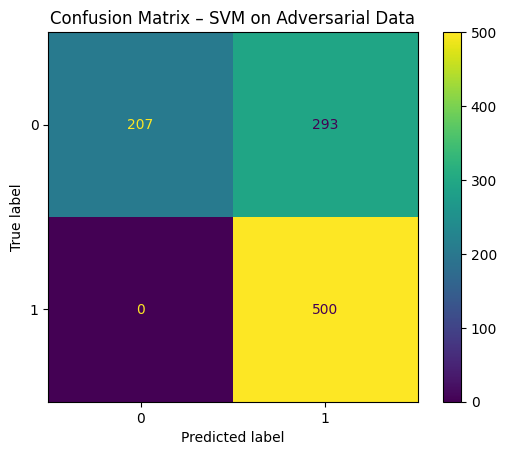

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(df_adversarial["risk_label"], y_adv_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix – SVM on Adversarial Data")
plt.show()


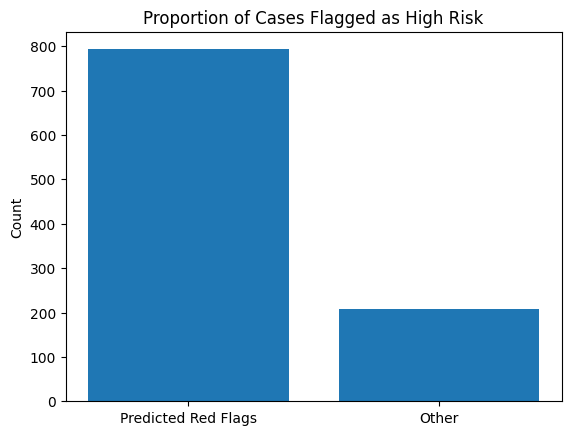

In [20]:
total = len(df_adversarial)
pred_red = sum(y_adv_pred_svm == "red_flag")

plt.figure()
plt.bar(["Predicted Red Flags", "Other"], [pred_red, total - pred_red])
plt.title("Proportion of Cases Flagged as High Risk")
plt.ylabel("Count")
plt.show()

# Risk Analysis

## 1. Risk of False Positives (Over-Flagging Clean Proposals)

Description:
The SVM baseline model exhibits high recall for red_flag cases but relatively low recall for clean cases. This results in a significant number of clean proposals being incorrectly classified as high risk.

Impact:
-Operational inefficiency due to unnecessary compliance reviews
-Increased workload for governance teams
-Reduced trust in the AI system over time

Mitigation Strategy:
-Introduce a secondary LLM-based audit layer to validate flagged cases
-Implement human-in-the-loop review for borderline cases
-Monitor false positive rate as a governance KPI

### 2. Synthetic Dataset Risk

Description:
The baseline model was trained primarily on synthetic project proposals. Although the dataset was intentionally structured and balanced, synthetic data may not accurately capture the linguistic variability, ambiguity, and complexity of real-world enterprise documentation (e.g., Jira tickets, Confluence pages).

Impact:
-Overfitting to repetitive or template-like phrasing
-Reduced generalization to real organizational documents
-Inflated evaluation performance compared to real deployment conditions

Mitigation Strategy:
-Gradually incorporate real-world project proposals into the training dataset
-Evaluate the model on adversarial and noisy test samples
-Perform periodic re-training using real enterprise data

### 3. Risk of Automation Bias

Description:
Users may overly rely on the system’s output (either SVM or LLM audit) without critically evaluating the reasoning behind the decision.

Impact:
-Blind acceptance of incorrect classifications
-Reduced human oversight
-Potential regulatory non-compliance if model errors go unnoticed

Mitigation Strategy:
-Provide structured explanations alongside risk labels
-Require human approval for high-risk classifications
-Clearly communicate that the system is a decision-support tool, not a final authority

# Fairness Analysis

### Fairness Analysis (Length-Based)

The model was evaluated across short and long proposal groups to assess structural fairness. Performance metrics (precision, recall, F1-score) were identical across both groups (1.00), indicating no observable length-based disparity.

However, perfect classification performance suggests the synthetic dataset may be overly separable. This limits the interpretability of fairness evaluation, as no misclassification variance exists across groups.

In [24]:
df_adversarial["svm_pred"] = y_adv_pred_svm

df_red = df_adversarial[df_adversarial["svm_pred"] == "red_flag"].copy()

print("Number of cases sent to LLM:", len(df_red))

Number of cases sent to LLM: 793


# LLM Audit 

In [25]:
import requests
import json

def run_local_llm_structured(description):

    prompt = f"""
You are an EU AI Act compliance auditor.

Respond ONLY in valid JSON with this exact format:

{{
  "risk_category": "Prohibited | High-Risk | Limited | Minimal",
  "violation_type": "...",
  "explanation": "...",
  "mitigation_steps": "..."
}}

Proposal:
{description}
"""

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3",
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0}
        }
    )

    raw_output = response.json()["response"]

    try:
        parsed = json.loads(raw_output)
    except:
        parsed = {
            "risk_category": "parse_error",
            "violation_type": None,
            "explanation": raw_output,
            "mitigation_steps": None
        }

    #  Format into readable report
    formatted_report = f"""
------------------------------
PROPOSAL:
{description}

RISK CATEGORY:
{parsed['risk_category']}

VIOLATION TYPE:
{parsed['violation_type']}

EXPLANATION:
{parsed['explanation']}

MITIGATION STEPS:
{parsed['mitigation_steps']}
------------------------------
"""

    return formatted_report

In [26]:
print(run_local_llm_structured(df_red.iloc[0]["description"]))


------------------------------
PROPOSAL:
The Risk Management department seeks to improve risk visibility. The initiative aims to modernize analytics capabilities. The solution will integrate with existing enterprise platforms. Cloud-native infrastructure will support modular expansion. Engagement metrics may guide internal classification processes.

RISK CATEGORY:
Limited

VIOLATION TYPE:
Data Protection

EXPLANATION:
The proposal's focus on integrating with existing enterprise platforms and using cloud-native infrastructure may involve processing personal data. However, the initiative does not explicitly mention data minimization, pseudonymization, or encryption, which are essential for ensuring the security and confidentiality of personal data.

MITIGATION STEPS:
Implement data minimization and pseudonymization techniques to ensure that only necessary personal data is processed. Conduct a data protection impact assessment (DPIA) to identify and mitigate potential risks. Develop a co

In [27]:
df_red_sample = df_red.head(3).copy()
df_red_sample["llm_audit_report"] = df_red_sample["description"].apply(run_local_llm_structured)

df_red_sample[["llm_audit_report"]]

,llm_audit_report
0,\n------------------------------\nPROPOSAL:\nT...
2,\n------------------------------\nPROPOSAL:\nT...
3,\n------------------------------\nPROPOSAL:\nT...


In [28]:
with open("llm_audit_reports.txt", "w") as f:
    for report in df_red_sample["llm_audit_report"]:
        f.write(report)
        f.write("\n\n")

# WEEK-3 Analyze the Model

### Feature Importance Analysis

In [29]:
feature_names = vectorizer.get_feature_names_out()
coefs = svm_model.coef_[0]

top_positive = coefs.argsort()[-20:]
top_negative = coefs.argsort()[:20]

print("Top Red Flag Indicators:")
for idx in reversed(top_positive):
    print(feature_names[idx], coefs[idx])

print("\nTop Clean Indicators:")
for idx in top_negative:
    print(feature_names[idx], coefs[idx])

Top Red Flag Indicators:
prioritization 1.9461531265784884
strategic 1.3172127357166807
behavior 1.3172127357166807
identity 1.2555876897496299
analyzed 1.162477912771477
predictive 1.1020053740731892
automated 1.0771936427128632
behavioral 1.0673095071944534
interaction 1.0276455656615386
inform 1.0173283642425153
indicators 1.0090367418128492
historical 0.9413832349557332
internal 0.8078330180036157
monitoring 0.8078330180036157
based 0.8078330180036157
camera 0.8078330180036157
algorithmic 0.7595676322856715
recruitment 0.7595676322856715
workflow 0.7595676322856715
candidate 0.7595676322856715

Top Clean Indicators:
operational -0.7089981007134295
capabilities -0.6859565099932102
opportunity -0.6859565099932102
department -0.6859565099932102
identified -0.6859565099932102
initiative -0.6859565099932102
advanced -0.6859565099932102
aims -0.6859565099932102
gains -0.6261593194790074
anticipated -0.6261593194790074
cloud -0.5726317706470159
expansion -0.5726317706470159
infrastructure

# XAI for in depth understanding of model

In [30]:
pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Model Explainability Analysis

To understand the decision-making process of the classifier, explainable AI (XAI) techniques were applied. 

First, global feature importance was analyzed using the linear model coefficients. The model relies heavily on specific keywords such as "identity" and "prioritization" to identify potentially risky proposals. These terms correspond to biometric monitoring and automated decision-making scenarios defined in the EU AI Act.

Second, SHAP values were used to visualize feature contributions across multiple samples. The summary plot revealed that certain lexical indicators consistently push predictions toward the red_flag category.

Finally, local explanations were generated for individual proposals using SHAP waterfall plots. These explanations highlight which specific words in a proposal contributed to its classification.

The analysis shows that the model primarily relies on lexical signals rather than deeper semantic understanding, which may limit generalization to real-world documents.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coefficients
})

top_red = importance_df.sort_values("weight", ascending=False).head(15)
top_clean = importance_df.sort_values("weight").head(15)

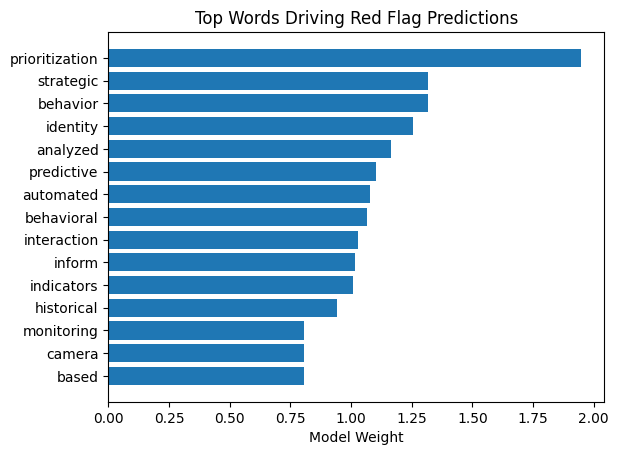

In [33]:
plt.figure()
plt.barh(top_red["feature"], top_red["weight"])
plt.title("Top Words Driving Red Flag Predictions")
plt.xlabel("Model Weight")
plt.gca().invert_yaxis()
plt.show()

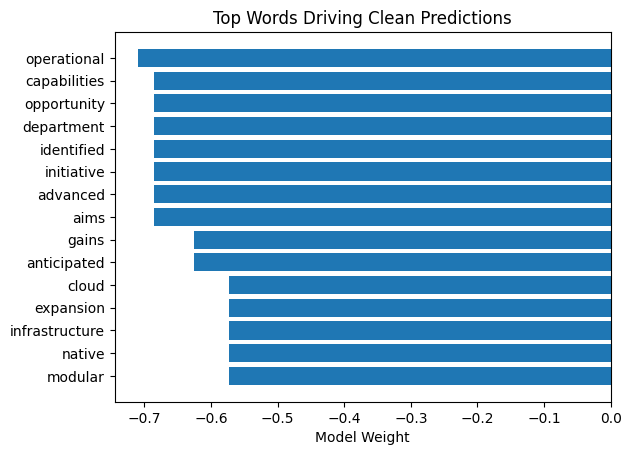

In [34]:
plt.figure()
plt.barh(top_clean["feature"], top_clean["weight"])
plt.title("Top Words Driving Clean Predictions")
plt.xlabel("Model Weight")
plt.gca().invert_yaxis()
plt.show()

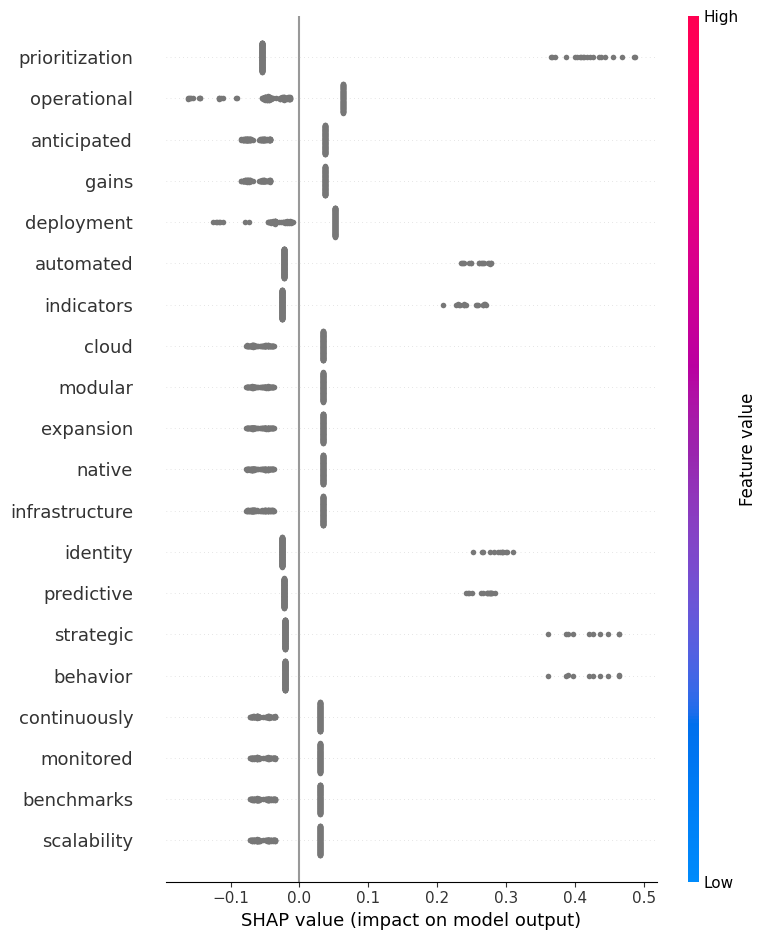

In [35]:
import shap

explainer = shap.LinearExplainer(svm_model, X_train_vec)

sample = X_test_vec[:200]

shap_values = explainer(sample)

shap.summary_plot(
    shap_values,
    sample,
    feature_names=vectorizer.get_feature_names_out()
)

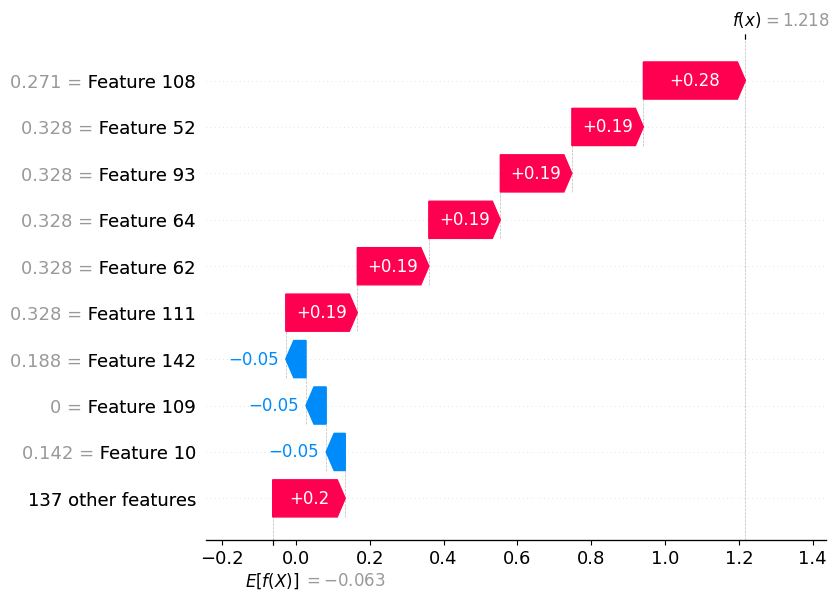

In [36]:
index = 5

sample = X_test_vec[index]

shap_values = explainer(sample)

shap.plots.waterfall(shap_values[0])

### Local Model Explanation

To better understand individual model decisions, SHAP waterfall plots were used to explain predictions for specific proposals. 

The explanation revealed that certain lexical indicators strongly influence classification outcomes. Words associated with automated decision-making or identity verification significantly increased the likelihood of a red_flag prediction. 

In the analyzed example, multiple features contributed positively toward the risk classification, resulting in a large shift from the baseline prediction value to a strong red_flag output.

While this demonstrates the model's ability to identify risk-related language, the explanation also highlights a potential limitation: the classifier relies heavily on specific keywords rather than deeper contextual reasoning.

# Tests to automatically detect weaknesses

## 1. Test for Keyword Over-Reliance

In [40]:
def test_keyword_over_reliance():

    text = "Task prioritization framework for infrastructure upgrades."

    pred = svm_model.predict(vectorizer.transform([text]))[0]

    print("Prediction:", pred)

    if pred != "clean":
        print("Weakness detected: Model over-relies on generic keywords.")
    else:
        print("Test passed: Model correctly identifies non-risky text.")

In [41]:
test_keyword_over_reliance()

Prediction: red_flag
Weakness detected: Model over-relies on generic keywords.


### Test for Keyword Over-Reliance

A potential weakness of text classification models using TF-IDF features is **over-reliance on specific keywords**. If the model associates certain words strongly with a risk label, it may incorrectly classify otherwise harmless proposals that contain those words.

To evaluate this behavior, an automated test was implemented. The test provides a neutral proposal containing terms such as *"prioritization"* and *"infrastructure upgrades"*, which may appear frequently in risky training examples but do not inherently indicate policy violations.

Example test input:

"Task prioritization framework for infrastructure upgrades."

Expected behavior:

The model should classify the proposal as **clean**, since the description does not include any high-risk activities such as biometric monitoring, behavioral profiling, or automated decision making affecting individuals.



# 2. Noise Robustness test

In [42]:
def test_noise_robustness():

    text = "Applicant suitability assessments will be derived from performance indicators."

    noisy_text = text + " Operational scalability improvements are expected."

    pred_original = svm_model.predict(vectorizer.transform([text]))[0]
    pred_noisy = svm_model.predict(vectorizer.transform([noisy_text]))[0]

    print("Original prediction:", pred_original)
    print("Noisy prediction:", pred_noisy)

    assert pred_original == pred_noisy


test_noise_robustness()

Original prediction: red_flag
Noisy prediction: red_flag


### Noise Robustness Test

An automated robustness test was implemented to evaluate whether the model is sensitive to irrelevant textual noise.

The test compares the model's prediction for an original proposal with a modified version that includes additional unrelated business context.

Example:

Original text:
"Applicant suitability assessments will be derived from performance indicators."

Noisy text:
"Applicant suitability assessments will be derived from performance indicators. Operational scalability improvements are expected."

Result:
Both inputs were classified as **red_flag**, indicating that the model's prediction remained stable despite the additional noise.

Conclusion:
The classifier demonstrates robustness to irrelevant business context and does not change predictions due to minor textual variations.

# Autonomous Compliance Sentinel (agentic AI governance system.)

### Monitoring Agent (Data Ingestion)

In [43]:
def monitoring_agent(df):

    print("Monitoring Agent: Retrieving proposals...")

    proposals = df[["title","description"]]

    return proposals

### Risk Detection Agent (ML Model)

In [44]:
def risk_detection_agent(proposals):

    print("Risk Detection Agent: Classifying proposals...")

    vectors = vectorizer.transform(proposals["description"])

    predictions = svm_model.predict(vectors)

    proposals["risk_prediction"] = predictions

    return proposals

### Explainability Agent (SHAP)

In [45]:
def explainability_agent(proposals):

    print("Explainability Agent: Generating explanations...")

    explanations = []

    for text in proposals["description"]:

        vec = vectorizer.transform([text])

        shap_values = explainer(vec)

        explanations.append(shap_values.values.sum())

    proposals["explanation_score"] = explanations

    return proposals

### Compliance Reporting Agent

In [46]:
def compliance_reporting_agent(proposals):

    print("Compliance Agent: Generating compliance report...")

    proposals["action"] = proposals["risk_prediction"].apply(
        lambda x: " Review Required" if x == "red_flag" else "Approved"
    )

    return proposals

### Main Agent Controller

In [47]:
def compliance_sentinel_system(df):

    proposals = monitoring_agent(df)

    proposals = risk_detection_agent(proposals)

    proposals = explainability_agent(proposals)

    report = compliance_reporting_agent(proposals)

    return report

In [49]:
final_report = compliance_sentinel_system(df_proposals)

final_report.head(100)

Monitoring Agent: Retrieving proposals...
Risk Detection Agent: Classifying proposals...
Explainability Agent: Generating explanations...
Compliance Agent: Generating compliance report...


/var/folders/mh/c2ztw8vj0sd79hj781zt9_1h0000gn/T/ipykernel_89333/2503621257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proposals["risk_prediction"] = predictions


,title,description,risk_prediction,explanation_score,action
0,Customer Analytics AI Initiative – de29e8,The Customer Analytics department has identifi...,clean,-0.851210,Approved
1,Customer Analytics AI Initiative – 84a741,The Customer Analytics department has identifi...,red_flag,1.016652,Review Required
2,Customer Analytics AI Initiative – fc917d,The Customer Analytics department has identifi...,red_flag,0.917695,Review Required
3,Security Operations AI Initiative – 1edf9c,The Security Operations department has identif...,red_flag,0.878627,Review Required
4,Human Resources AI Initiative – d32ee7,The Human Resources department has identified ...,clean,-0.897086,Approved
...,...,...,...,...,...
95,Customer Analytics AI Initiative – e5a264,The Customer Analytics department has identifi...,red_flag,0.907213,Review Required
96,Finance AI Initiative – fba413,The Finance department has identified an oppor...,clean,-0.874329,Approved
97,Risk Management AI Initiative – e964d9,The Risk Management department has identified ...,clean,-0.936727,Approved
98,IT Governance AI Initiative – 04a125,The IT Governance department has identified an...,clean,-0.912199,Approved


In [50]:
import pickle

# save trained model
pickle.dump(svm_model, open("svm_model.pkl", "wb"))

# save TF-IDF vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Pseudo Model Card — AI Compliance Sentinel

## 1. Model Overview

The AI Compliance Sentinel model is designed to analyze textual descriptions of AI project proposals and identify potential regulatory compliance risks.  
The system classifies proposals into two categories:

- **Clean** – The proposal appears compliant with minimal regulatory concerns.
- **Red Flag** – The proposal may contain elements associated with potential regulatory risks and requires further review.

The model is intended to support early-stage AI governance by assisting organizations in identifying risky AI initiatives before deployment.

---

## 2. Model Architecture

The model pipeline consists of the following components:

Proposal Text  
↓  
TF-IDF Vectorization  
↓  
Support Vector Machine (SVM) Classifier  
↓  
Risk Prediction (Clean / Red Flag)  
↓  
Explanation Score (Distance from Decision Boundary)

The model uses:

- **TF-IDF** for transforming textual proposals into numerical feature vectors.
- **Linear Support Vector Machine (SVM)** for binary classification.

---

## 3. Training Data

The training dataset consists of **synthetic AI project proposals** designed to simulate realistic enterprise AI initiatives.

Dataset characteristics:

- Total proposals: **1000**
- Clean proposals: **500**
- Risky proposals: **500**

Risk categories simulated in the dataset include:

- automated hiring systems
- behavioral profiling
- biometric monitoring
- reputation scoring systems

Synthetic data was used due to the **lack of publicly available datasets containing AI governance documentation**.

---

## 4. Evaluation

The model was evaluated using a held-out test dataset and adversarial test cases.

Evaluation metrics included:

- Accuracy
- Precision
- Recall
- F1 Score

Additional robustness tests were conducted using:

- adversarial proposals
- ambiguous proposals
- keyword-modified proposals

These tests help evaluate whether the model detects genuine semantic signals rather than simple keyword matches.

---

## 5. Explainability

The system provides an **explanation score** based on the SVM decision function.

Interpretation of the explanation score:

- **Positive values** indicate stronger similarity with risky proposal patterns.
- **Negative values** indicate lower regulatory risk.
- **Magnitude of the score** reflects the model's confidence in the prediction.

This score helps users understand how strongly the proposal aligns with potential regulatory risk patterns.

---

## 6. Limitations

Several limitations should be considered when interpreting model outputs:

### Synthetic Dataset Limitation
The model is trained on synthetic proposals, which may not fully capture the linguistic diversity of real enterprise documentation.

### Limited Regulatory Coverage
The model focuses on a small subset of risk scenarios and does not implement the full complexity of regulations such as the EU AI Act or GDPR.

### Keyword Sensitivity
Although the model uses statistical learning, some predictions may still be influenced by certain keywords or phrases present in the training data.

### Domain Dependency
The model performs best on structured AI proposals and may struggle with informal descriptions or incomplete documentation.

---

## 7. Potential Biases

Potential sources of bias include:

- **Dataset bias** due to synthetic proposal generation patterns.
- **Topic bias** if certain departments or AI use cases appear more frequently in the dataset.
- **Language bias** if proposals follow specific corporate writing styles.

These biases could influence how the model interprets certain proposals.

---

## 8. Potential Attacks

Several adversarial scenarios could impact model performance:

### Keyword Manipulation
Users could intentionally rephrase risky proposals using neutral language to avoid detection.

### Adversarial Wording
Subtle language modifications may alter model predictions without changing the underlying risk.

### Proposal Obfuscation
Important risk signals could be hidden within large amounts of irrelevant text.

Testing with adversarial examples helps evaluate the robustness of the model.

---

## 9. Usage Restrictions

The model should **not be used as a final compliance authority**.

Recommended usage:

- preliminary risk screening
- compliance decision support
- governance workflow assistance

All final regulatory decisions should involve **human oversight and expert review**.

---

## 10. Future Improvements

Potential improvements include:

- training on real enterprise AI governance datasets
- integrating semantic language models (e.g., transformer-based models)
- expanding regulatory rule coverage
- improving explainability through advanced XAI methods

---

## 11. Version Information

Model Version: **v1.0**

Algorithm: **Support Vector Machine (Linear SVM)**  
Feature Representation: **TF-IDF**  

Deployment Components:

- Python
- Scikit-learn
- Streamlit interface
- Jira integration for compliance tracking